# Phase 5 (IHDS-II) — Explainability

[`walkthrough/ihds_phase5.md`](../walkthrough/ihds_phase5.md)

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../dataset/ihds2_features.csv")

CATEGORICALS = ["Occupation", "Area_Type", "Caste_Group", "Religion"]
DROP = ["IDHH", "WT", "Goal_Met", "Savings_Rate"] + [c for c in df.columns if c.endswith("_CLR")]
NUMERIC = [c for c in df.columns if c not in DROP + CATEGORICALS]
SHARE_COLS = [c for c in NUMERIC if c.endswith("_Share")]

X, y = df[NUMERIC + CATEGORICALS], df["Goal_Met"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", RobustScaler())]), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICALS),
])

# Phase 4's winning configuration, fitted on transformed data so SHAP sees named columns.
Xt_train = pre.fit_transform(X_train)
Xt_test = pre.transform(X_test)
FEATURE_NAMES = list(NUMERIC) + list(
    pre.named_transformers_["cat"].get_feature_names_out(CATEGORICALS)
)
Xt_train = pd.DataFrame(Xt_train, columns=FEATURE_NAMES)
Xt_test = pd.DataFrame(Xt_test, columns=FEATURE_NAMES)

model = XGBClassifier(max_depth=4, learning_rate=0.15, n_estimators=200, min_child_weight=5,
                      subsample=0.9, eval_metric="logloss", random_state=42, n_jobs=-1)
model.fit(Xt_train, y_train)
print(f"encoded features: {len(FEATURE_NAMES)}   train: {Xt_train.shape}   test: {Xt_test.shape}")
print(f"test accuracy: {model.score(Xt_test, y_test):.4f}")

encoded features: 50   train: (33214, 50)   test: (8304, 50)
test accuracy: 0.8615


## The identification problem Phase 2 flagged

Phase 2 measured VIF = ∞ for all 11 shares: they sum to 1, so one is an exact linear combination
of the other ten. Before reading any explanation, this cell establishes what that does to
coefficient-based interpretation — and why SHAP on the tree model is used instead.

In [2]:
# Fit the SAME linear model on 5 disjoint subsamples. If the shares were identified,
# the coefficients would be stable across them.
rng = np.random.default_rng(42)
folds = np.array_split(rng.permutation(len(Xt_train)), 5)

coefs = []
for i, idx in enumerate(folds):
    lr = LogisticRegression(max_iter=5000, class_weight="balanced", C=100.0)
    lr.fit(Xt_train.iloc[idx], y_train.iloc[idx])
    coefs.append(pd.Series(lr.coef_[0], index=FEATURE_NAMES))
coef_df = pd.concat(coefs, axis=1)

summary = pd.DataFrame({"mean": coef_df.mean(axis=1), "sd": coef_df.std(axis=1)})
summary["sd/|mean|"] = summary["sd"] / summary["mean"].abs()
summary["flips_sign"] = (coef_df > 0).any(axis=1) & (coef_df < 0).any(axis=1)

print("Coefficient stability across 5 disjoint subsamples, share features:")
print(summary.loc[SHARE_COLS, ["mean", "sd", "sd/|mean|", "flips_sign"]].round(3).to_string())
print("\nSame diagnostic for non-compositional features (control group):")
control = ["Log_Income", "Head_Age", "Household_Size", "Debt_To_Income_W", "Max_Adult_Education"]
print(summary.loc[control, ["mean", "sd", "sd/|mean|", "flips_sign"]].round(3).to_string())
print(f"\nshare features that flip sign across subsamples: "
      f"{summary.loc[SHARE_COLS, 'flips_sign'].sum()} of {len(SHARE_COLS)}")
print(f"control features that flip sign:                 "
      f"{summary.loc[control, 'flips_sign'].sum()} of {len(control)}")

Coefficient stability across 5 disjoint subsamples, share features:
                          mean     sd  sd/|mean|  flips_sign
Groceries_Share          1.084  0.163      0.150       False
Eating_Out_Share         0.035  0.020      0.555       False
Utilities_Share          0.531  0.077      0.146       False
Rent_Share              -0.368  0.062      0.167       False
Transport_Share         -0.208  0.076      0.365       False
Healthcare_Share        -0.204  0.132      0.648        True
Education_Share         -0.112  0.043      0.386       False
Entertainment_Share     -0.017  0.010      0.603        True
Insurance_Share          0.006  0.011      1.808        True
Clothing_Footwear_Share  0.300  0.089      0.296       False
Miscellaneous_Share     -0.258  0.052      0.200       False

Same diagnostic for non-compositional features (control group):
                      mean     sd  sd/|mean|  flips_sign
Log_Income           4.640  0.133      0.029       False
Head_Age             

In [3]:
# The reference-part fix: drop one share so the remaining ten are no longer collinear.
# Every remaining coefficient is then read RELATIVE to the dropped part.
REFERENCE = "Groceries_Share"
reduced = [c for c in FEATURE_NAMES if c != REFERENCE]

coefs_r = []
for idx in folds:
    lr = LogisticRegression(max_iter=5000, class_weight="balanced", C=100.0)
    lr.fit(Xt_train.iloc[idx][reduced], y_train.iloc[idx])
    coefs_r.append(pd.Series(lr.coef_[0], index=reduced))
coef_r = pd.concat(coefs_r, axis=1)

other_shares = [c for c in SHARE_COLS if c != REFERENCE]
comp = pd.DataFrame({
    "sd (all 11 shares)": coef_df.loc[other_shares].std(axis=1),
    "sd (reference part dropped)": coef_r.loc[other_shares].std(axis=1),
})
comp["improvement"] = comp["sd (all 11 shares)"] / comp["sd (reference part dropped)"]
print(f"Dropping {REFERENCE} as the reference part:")
print(comp.round(3).to_string())
print(f"\nmedian reduction in coefficient sd: {comp['improvement'].median():.2f}x")

Dropping Groceries_Share as the reference part:
                         sd (all 11 shares)  sd (reference part dropped)  improvement
Eating_Out_Share                      0.020                        0.018        1.102
Utilities_Share                       0.077                        0.083        0.932
Rent_Share                            0.062                        1.027        0.060
Transport_Share                       0.076                        0.056        1.343
Healthcare_Share                      0.132                        0.059        2.239
Education_Share                       0.043                        0.009        4.883
Entertainment_Share                   0.010                        0.011        0.950
Insurance_Share                       0.011                        0.007        1.691
Clothing_Footwear_Share               0.089                        0.088        1.006
Miscellaneous_Share                   0.052                        0.016        3.306

media

## Q1 — Which features matter most globally?

In [4]:
# XGBoost's own TreeSHAP. Mathematically identical to shap.TreeExplainer, but shap 0.49
# cannot parse xgboost 3.x's base_score format, so the native path is used instead.
import xgboost as xgb

contribs = model.get_booster().predict(xgb.DMatrix(Xt_test), pred_contribs=True)
shap_values, bias = contribs[:, :-1], contribs[:, -1]
print("SHAP values:", shap_values.shape, "  bias term:", round(float(bias[0]), 4))
print("additivity check (SHAP sum + bias vs raw margin): max abs error =",
      f"{np.abs(shap_values.sum(1) + bias - model.get_booster().predict(xgb.DMatrix(Xt_test), output_margin=True)).max():.2e}")

global_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_NAMES).sort_values(ascending=False)
print("\nGlobal importance (mean |SHAP|), top 15:")
print(global_imp.head(15).round(4).to_string())

print("\nShare of total importance by feature group:")
groups = {
    "Income (Log_Income)": ["Log_Income"],
    "Spending mix (11 shares)": SHARE_COLS,
    "Participation indicators": [c for c in NUMERIC if c.startswith("Spends_On_")],
    "Debt": ["Debt_To_Income_W", "Has_Debt"],
    "Household composition": ["Household_Size", "Dependents", "Dependency_Ratio", "Head_Age"],
    "Education": ["Max_Adult_Education"],
    "Categorical (all levels)": [c for c in FEATURE_NAMES if c not in NUMERIC],
}
grp = pd.Series({k: global_imp[[c for c in v if c in global_imp.index]].sum() for k, v in groups.items()})
print((grp / grp.sum()).sort_values(ascending=False).round(4).to_string())

SHAP values: (8304, 50)   bias term: -0.8069
additivity check (SHAP sum + bias vs raw margin): max abs error = 8.58e-06

Global importance (mean |SHAP|), top 15:
Log_Income                  2.6170
Household_Size              0.5755
Groceries_Share             0.5546
Utilities_Share             0.3136
Clothing_Footwear_Share     0.2204
Max_Adult_Education         0.2151
Debt_To_Income_W            0.2036
Transport_Share             0.1771
Healthcare_Share            0.1402
Occupation_Non_Ag_Labour    0.1390
Education_Share             0.1332
Dependency_Ratio            0.1214
Area_Type_Other_Urban       0.1018
Spends_On_Insurance         0.1016
Miscellaneous_Share         0.1015

Share of total importance by feature group:
Income (Log_Income)         0.3835
Spending mix (11 shares)    0.2672
Categorical (all levels)    0.1326
Household composition       0.1124
Participation indicators    0.0396
Debt                        0.0331
Education                   0.0315


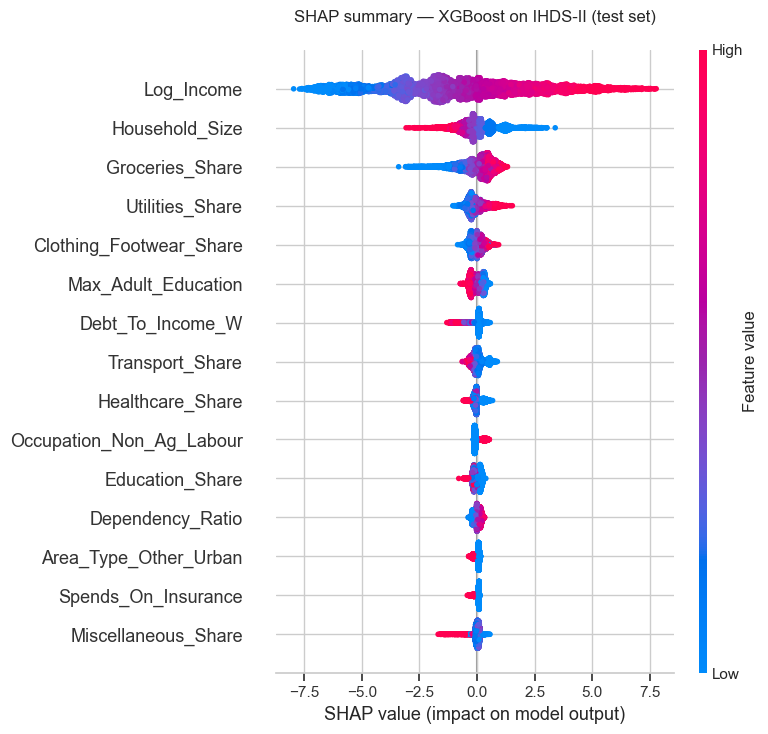

In [5]:
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, Xt_test.to_numpy(), feature_names=FEATURE_NAMES,
                  max_display=15, show=False)
plt.title("SHAP summary — XGBoost on IHDS-II (test set)", pad=20)
plt.tight_layout()
plt.savefig("../results/ihds_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## Q2 — Are there notable interaction effects?

In [6]:
# Does area type change how much dependents cost a household? This is the IHDS analogue
# of the synthetic project's "does City_Tier change the effect of Dependents" question.
sample = Xt_test.sample(min(3000, len(Xt_test)), random_state=42)
inter_full = model.get_booster().predict(xgb.DMatrix(sample), pred_interactions=True)
inter = inter_full[:, :-1, :-1]   # drop the bias row/column
print("interaction tensor:", inter.shape)

n = len(FEATURE_NAMES)
iv = np.abs(inter).mean(axis=0)
np.fill_diagonal(iv, 0)
pairs = (pd.DataFrame(iv, index=FEATURE_NAMES, columns=FEATURE_NAMES)
         .stack().sort_values(ascending=False))
pairs = pairs[pairs.index.get_level_values(0) < pairs.index.get_level_values(1)]
print("\nStrongest interaction pairs (mean |interaction SHAP|):")
print(pairs.head(10).round(5).to_string())

diag = pd.Series(np.abs(inter).mean(axis=0).diagonal(), index=FEATURE_NAMES)
print(f"\ntotal main effects:  {diag.sum():.4f}")
print(f"total interactions:  {pairs.sum() * 2:.4f}")
print(f"interactions as share of total: {pairs.sum() * 2 / (diag.sum() + pairs.sum() * 2):.2%}")

interaction tensor: (3000, 50, 50)

Strongest interaction pairs (mean |interaction SHAP|):
Groceries_Share          Log_Income             0.16632
Household_Size           Log_Income             0.10154
Log_Income               Utilities_Share        0.08910
Groceries_Share          Utilities_Share        0.04021
Log_Income               Max_Adult_Education    0.03561
                         Transport_Share        0.03514
Insurance_Share          Spends_On_Insurance    0.03021
Healthcare_Share         Log_Income             0.02924
Clothing_Footwear_Share  Log_Income             0.02851
Head_Age                 Log_Income             0.02830

total main effects:  6.5094
total interactions:  4.6893
interactions as share of total: 41.87%


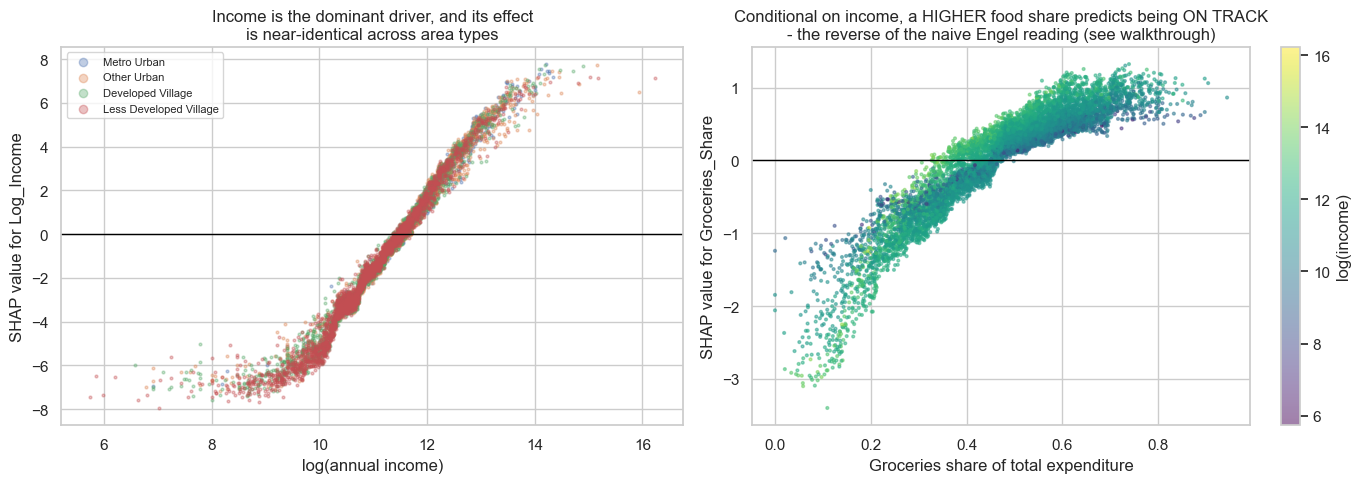

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

test_raw = X_test.reset_index(drop=True)
sv = pd.DataFrame(shap_values, columns=FEATURE_NAMES)

# Income dependence, coloured by area type
ax = axes[0]
for area in ["Metro_Urban", "Other_Urban", "Developed_Village", "Less_Developed_Village"]:
    m = test_raw["Area_Type"] == area
    ax.scatter(test_raw.loc[m, "Log_Income"], sv.loc[m.to_numpy(), "Log_Income"],
               s=4, alpha=0.35, label=area.replace("_", " "))
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("log(annual income)")
ax.set_ylabel("SHAP value for Log_Income")
ax.set_title("Income is the dominant driver, and its effect\nis near-identical across area types")
ax.legend(markerscale=3, fontsize=8)

# Groceries share dependence
ax = axes[1]
sc = ax.scatter(test_raw["Groceries_Share"], sv["Groceries_Share"],
                c=test_raw["Log_Income"], s=4, alpha=0.5, cmap="viridis")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Groceries share of total expenditure")
ax.set_ylabel("SHAP value for Groceries_Share")
ax.set_title("Conditional on income, a HIGHER food share predicts being ON TRACK\n"
             "- the reverse of the naive Engel reading (see walkthrough)")
plt.colorbar(sc, ax=ax, label="log(income)")

plt.tight_layout()
plt.savefig("../results/ihds_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

## Q3 — Can individual predictions be explained in plain business language?

In [8]:
def explain(i, top=5):
    row = test_raw.iloc[i]
    contrib = sv.iloc[i].sort_values(key=np.abs, ascending=False).head(top)
    p = model.predict_proba(Xt_test.iloc[[i]])[0, 1]
    print(f"Household #{i} — predicted P(on track) = {p:.1%}   actual: "
          f"{'on track' if y_test.iloc[i] == 1 else 'NOT on track'}")
    print(f"  income Rs {np.exp(row['Log_Income']):,.0f}/yr, "
          f"{int(row['Household_Size'])} people, {int(row['Dependents'])} dependents, "
          f"{row['Area_Type'].replace('_', ' ')}, {row['Occupation'].replace('_', ' ')}")
    for feat, val in contrib.items():
        direction = "toward ON TRACK" if val > 0 else "toward NOT on track"
        raw = row[feat] if feat in row.index else "(category)"
        raw_s = f"{raw:.3f}" if isinstance(raw, (int, float, np.floating)) else raw
        print(f"    {val:+.3f}  {direction:22s} {feat} = {raw_s}")
    print()


proba_all = model.predict_proba(Xt_test)[:, 1]
print("=" * 78)
print("MOST CONFIDENT 'ON TRACK'")
print("=" * 78)
explain(int(np.argmax(proba_all)))
print("=" * 78)
print("MOST CONFIDENT 'NOT ON TRACK'")
print("=" * 78)
explain(int(np.argmin(proba_all)))
print("=" * 78)
print("A BORDERLINE CASE (predicted probability closest to 50%)")
print("=" * 78)
explain(int(np.argmin(np.abs(proba_all - 0.5))))

MOST CONFIDENT 'ON TRACK'
Household #363 — predicted P(on track) = 100.0%   actual: on track
  income Rs 1,158,000/yr, 2 people, 0 dependents, Less Developed Village, Ag Labour
    +6.737  toward ON TRACK        Log_Income = 13.962
    +0.929  toward ON TRACK        Household_Size = 2
    +0.470  toward ON TRACK        Groceries_Share = 0.465
    +0.343  toward ON TRACK        Debt_To_Income_W = 0.022
    +0.218  toward ON TRACK        Occupation_Ag_Labour = (category)

MOST CONFIDENT 'NOT ON TRACK'
Household #6047 — predicted P(on track) = 0.0%   actual: NOT on track
  income Rs 2,990/yr, 7 people, 4 dependents, Less Developed Village, Farm
    -5.653  toward NOT on track    Log_Income = 8.003
    -1.160  toward NOT on track    Miscellaneous_Share = 0.716
    -0.977  toward NOT on track    Groceries_Share = 0.206
    -0.972  toward NOT on track    Debt_To_Income_W = 10.234
    -0.744  toward NOT on track    Household_Size = 7

A BORDERLINE CASE (predicted probability closest to 50%)
H

In [9]:
global_imp.head(20).to_csv("../results/ihds_shap_importance.csv", header=["mean_abs_shap"])
print("wrote ../results/ihds_shap_importance.csv")
print("wrote ../results/ihds_shap_summary.png, ../results/ihds_shap_dependence.png")

wrote ../results/ihds_shap_importance.csv
wrote ../results/ihds_shap_summary.png, ../results/ihds_shap_dependence.png
